<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:orange; font-size:36px;">A Deep Learning and Big Data Approach for Predictive Customer Targeting in Bank Marketing Campaigns</h1>

<b>Author:</b> J.A Montuya<br />
<b>Student ID:</b> 2025040<br />
<h3>Abstract:</h3>
    

In [3]:
#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Install Packages
#!python3 -m pip install imblearn hdfs --break-system-packages
#!python3 -m pip install catboost --break-system-packages
#!pip install catboost


## Import Libraries

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import json
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from pyspark.sql.types import *
from pyspark.sql import functions
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from hdfs import InsecureClient

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

ModuleNotFoundError: No module named 'pyspark'

## Custom Functions

In [ ]:
# Save model locally and upload to HDFS
def save_model(model, scaler, filename):
    hdfs_path = f'/marketing_campaign/models/{filename}.h5'
    
    print('----Exporting model locally.')
    try:
        # Save model locally
        model.save(f'{filename}.h5')
        
        # Save scaler and encoder
        print('----Exporting scaler')
        joblib.dump(scaler, 'scaler.pkl')
    
        print(f'Model was saved locally as {filename}.h5')
    except Exception as e:
        print('Failed to export the model.')
        print('Error details:', e)
        
    
    # Upload file to HDFS
    try:
        client = InsecureClient('http://localhost:9870', user='hduser')
        print('----Uploading model to HDFS.')
        with open(f'{filename}.h5', 'rb') as f:
            client.write(hdfs_path, f, overwrite=True)
        print('----Uploading scaler to HDFS.')
       
        with open('scaler.pkl', 'rb') as a:
            client.write(f'/marketing_campaign/models/scaler.pkl', a, overwrite=True)

        print(f"Model saved to HDFS at {hdfs_path}")
    except Exception as e:
        print('Failed to upload model to HDFS.')
        print('Error details:', e)


# This function will initialize model training
# X - independent variables
# y - target variables
# model - dictionary of models to be used
# param_grid - corresponding parameter grid per model
# split_size - train, test split size with 20% default
# cv - number of folds
def init_training(X_train, y_train, X_test, y_test, model, param_grid, split_size=0.20, cv=3, print_results=True):

    # Create variables to store model and results
    results=[]
    trained_models={}

    #Loop through each model
    for name, clf in models.items():
        print(clf, name)
        grid_search = GridSearchCV(clf, param_grid[name], cv=cv, scoring='accuracy')

        # Fit the grid search
        grid_search.fit(X_train, y_train)
        
        # Best parameters and best score
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_
        
        # Get best model on the training data
        best_model = grid_search.best_estimator_

        # Predict Values
        X_pred = best_model.predict(X_train)
        y_pred = best_model.predict(X_test)
        
        # Store the Accuracy and F1
        train_acc = accuracy_score(y_train, X_pred)
        test_acc = accuracy_score(y_test, y_pred)
        
        train_f1 = f1_score(y_train, X_pred, average="weighted") 
        test_f1 = f1_score(y_test, y_pred, average="weighted")


        # Consolidate results
        results.append({'Model':name,
                    'Accuracy': test_acc,
                    'F1':test_f1,
                   })

        # Store best model
        trained_models[name]= best_model
        
        # Display the training and test score
        if print_results==True: 
            print(f'Model: {name}:')
            print(f'Best Params:{best_params}')
            print(f'Accuracy score for train:{train_acc: .4f}, test:{test_acc: .4f}.')
            print(f'F1 score for train: {train_f1:.4f}, test F1: {test_f1:.4f}')
            print('\n')
            print(classification_report(y_test, y_pred))
        else:
            pass

    # Return model training results and trained_models to be used for predictions
    return results, trained_models

# This function displays a performance comparison across all trained models
def gen_model_training_summary(result,title=''):
    # Convert to DataFrame and sort by R2 score
    results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=True)
    
    # Create subplots
    fig, ax = plt.subplots(2, 1, figsize=(15, 15))
    
    # Plot Accuracy Score
    sns.barplot(ax=ax[0], x=results_df.Model, y=results_df.Accuracy, palette="Blues")
    ax[0].set_title("Accuracy Score Comparison")
    ax[0].set_ylabel("Accuracy Score")
    ax[0].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Plot MAE
    sns.barplot(ax=ax[1], x=results_df.Model, y=results_df.F1, palette="Greens")
    ax[1].set_title("F1 Score Comparison")
    ax[1].set_ylabel("F1 Score")
    ax[1].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Adjust layout and show plot
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def check_outliers(data, feature_name):
    # Calculate the 25th and 75th percentiles
    Q1 = np.percentile(data[feature_name], 25)
    Q3 = np.percentile(data[feature_name], 75)
    # Calculate for IQR 
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    
    # Return records where the feature value is below the lower bound or above the upper bound
    outliers = data.loc[(data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)]
    return outliers


## Import Dataset from HDFS

In [ ]:
df = spark.read.load('hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv', format="csv", header="true")
df.printSchema()

In [10]:
# Convert data into a Pandas Dataframe 
#campaign_data=df.toPandas()
campaign_data=pd.read_csv('marketing_data.csv')
campaign_data.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


<br />
<center><h2>Data Preparation</h2></center>
<br />

In [29]:
# Analyze information of the data frame
campaign_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     8252 non-null   object
 17  target       45211 non-null  object
dtypes: int64(8), object(10)
memory usage: 6.2+ MB


        By extracting information from the dataframe, 45,211 records and 18 columns were identified. The dataset contains variables in both int64 and object formats. However, inconsistencies were observed in the Non-Null Count column; for example, the contact feature has only 32,191 records, indicating the presence of missing or null values in the dataset.

In [14]:
campaign_data.describe()

,Unnamed: 0,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22605.000000,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,13051.435847,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,0.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,11302.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,22605.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,33907.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,45210.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Null Checking

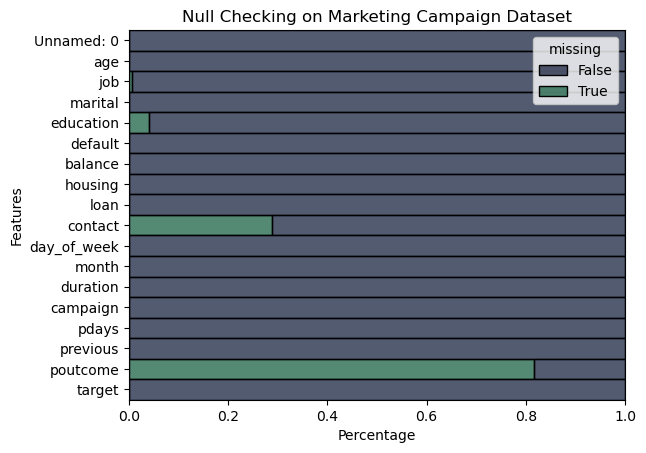

In [17]:
sns.set_palette('cubehelix')

sns.histplot(data=campaign_data.isnull().melt(value_name='missing'),
           y='variable',
           hue='missing',
           multiple='fill')

plt.title('Null Checking on Marketing Campaign Dataset')
plt.xlabel('Percentage')
plt.ylabel('Features')

plt.show()

#### Check for Duplicates

In [24]:
print(f'Number of duplicates in the dataframe: {campaign_data.duplicated().sum()}.')

Number of duplicates in the dataframe: 0.


#### Check for unique values
Examining the number of unique values helps determine whether a feature is categorical or numerical, and then we apply proper encoding methods to the dataframe.

In [569]:
# Check for unique 
campaign_data.nunique()

Unnamed: 0     45211
age               77
job               11
marital            3
education          3
default            2
balance         7168
housing            2
loan               2
contact            2
day_of_week       31
month             12
duration        1573
campaign          48
pdays            559
previous          41
poutcome           3
target             2
dtype: int64

## Data Preparation and Visualisation

<b>Convert features from Objects to Numeric

In [573]:
cols = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
campaign_data[cols] = campaign_data[cols].apply(pd.to_numeric, errors='coerce')

In [575]:
# Drop unusable features and separate data into dependent and independent variables
# Drop records containing null values
# try catch was implemented to avoid errors when rerunning the patch of code
try:
    df=campaign_data.copy()
    df.drop(columns=['_c0','poutcome','pdays', 'day_of_week','month'], inplace=True)    
    df.dropna(axis=0, inplace=True)
    y = df['target']
    X = df.drop(columns=['target'])
except Exception as e:
    print('No changes made in the dataset.')
    print(f'Exception:{e}')

X.isnull().sum()

No changes made in the dataset.
Exception:"['_c0'] not found in axis"


age                    0
default                0
balance                0
housing                0
loan                   0
duration               0
campaign               0
previous               0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
marital_married        0
marital_single         0
education_secondary    0
education_tertiary     0
dtype: int64

#### Projecting Marketing Campaign Acceptance by Age Group


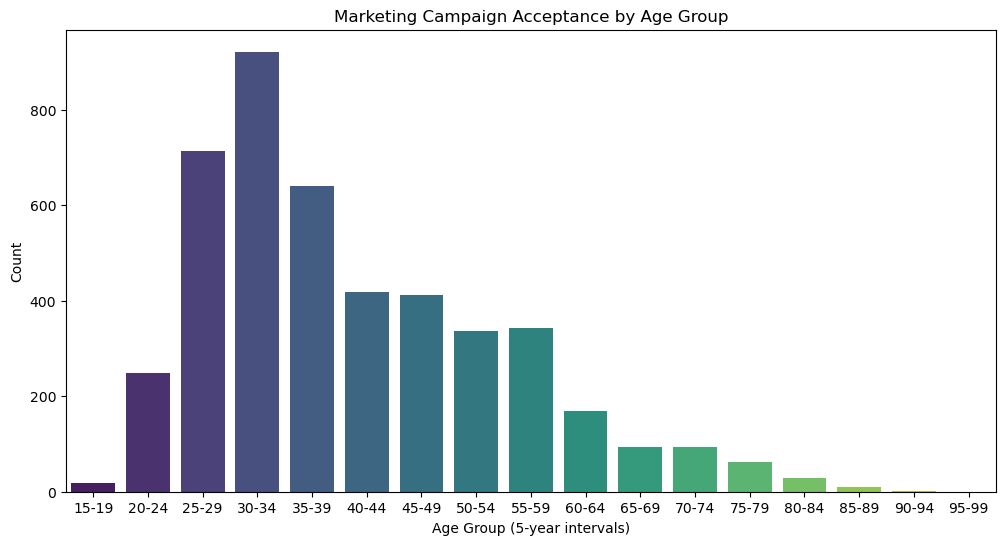

In [20]:
df_yes = df[df['target'] == 'yes'].copy() 

min_age = df_yes['age'].min() // 5 * 5
max_age = (df_yes['age'].max() // 5 + 1) * 5
bins = range(min_age, max_age + 1, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df_yes['age_group'] = pd.cut(df_yes['age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(12, 6))
sns.countplot(x='age_group', data=df_yes, order=labels, palette='viridis')
plt.xlabel('Age Group (5-year intervals)')
plt.ylabel('Count')
plt.title('Marketing Campaign Acceptance by Age Group')
plt.show()


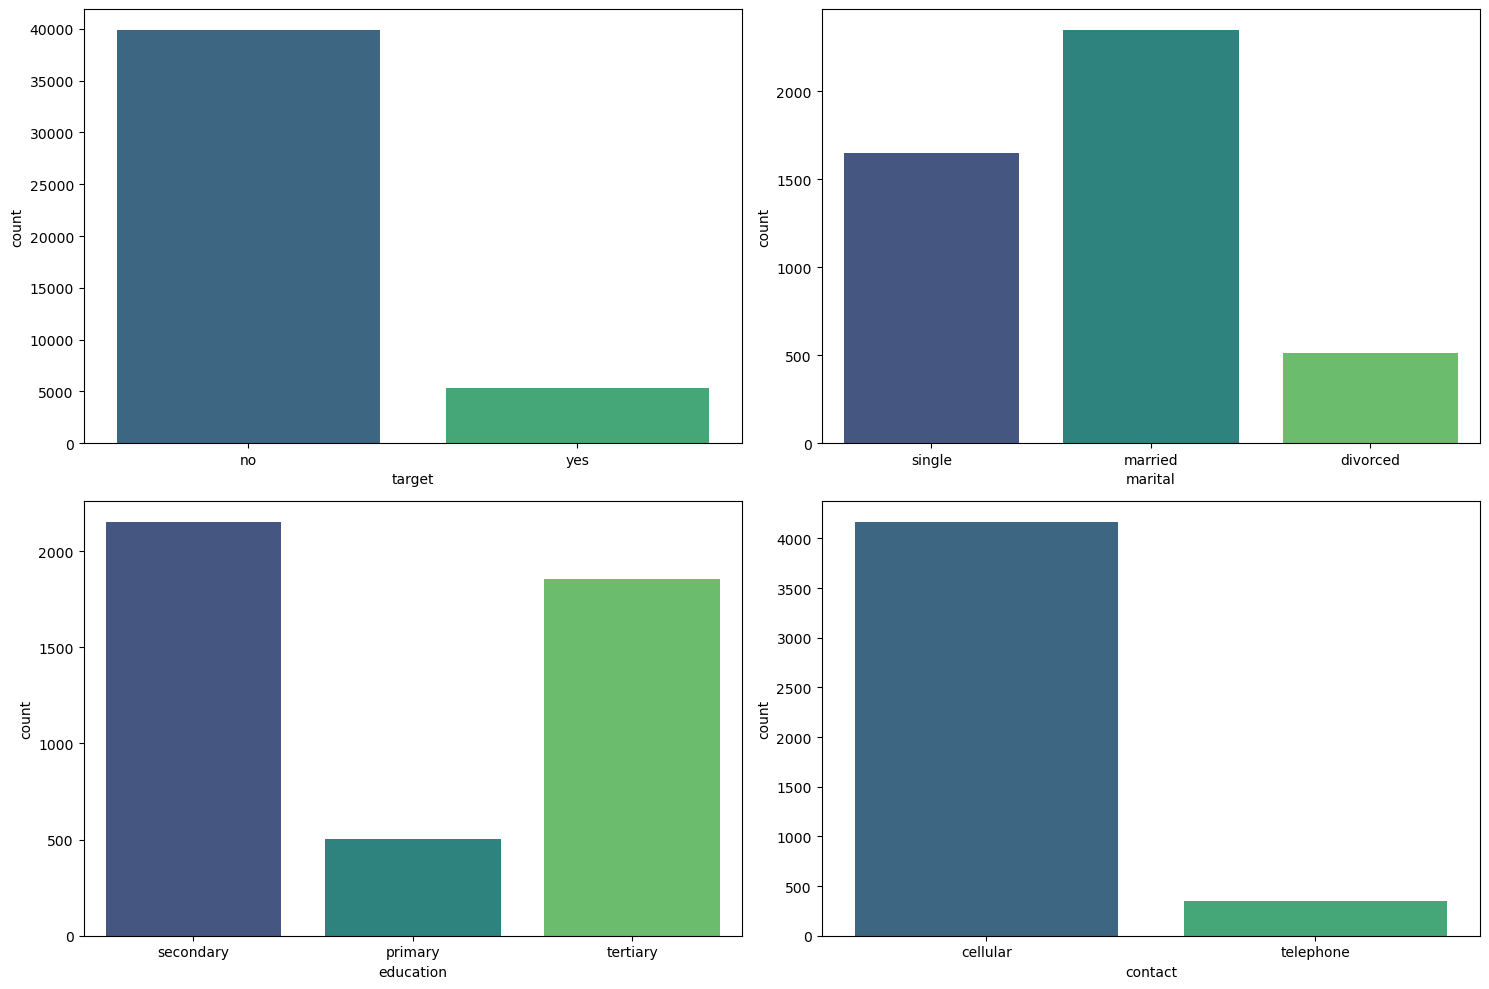

In [21]:

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten() 

sns.countplot(x='target', data=campaign_data, palette='viridis', ax=axs[0])
sns.countplot(x='marital', data=df_yes, palette='viridis', ax=axs[1])
sns.countplot(x='education', data=df_yes, palette='viridis', ax=axs[2])
sns.countplot(x='contact', data=df_yes, palette='viridis', ax=axs[3])

plt.tight_layout()
plt.show()


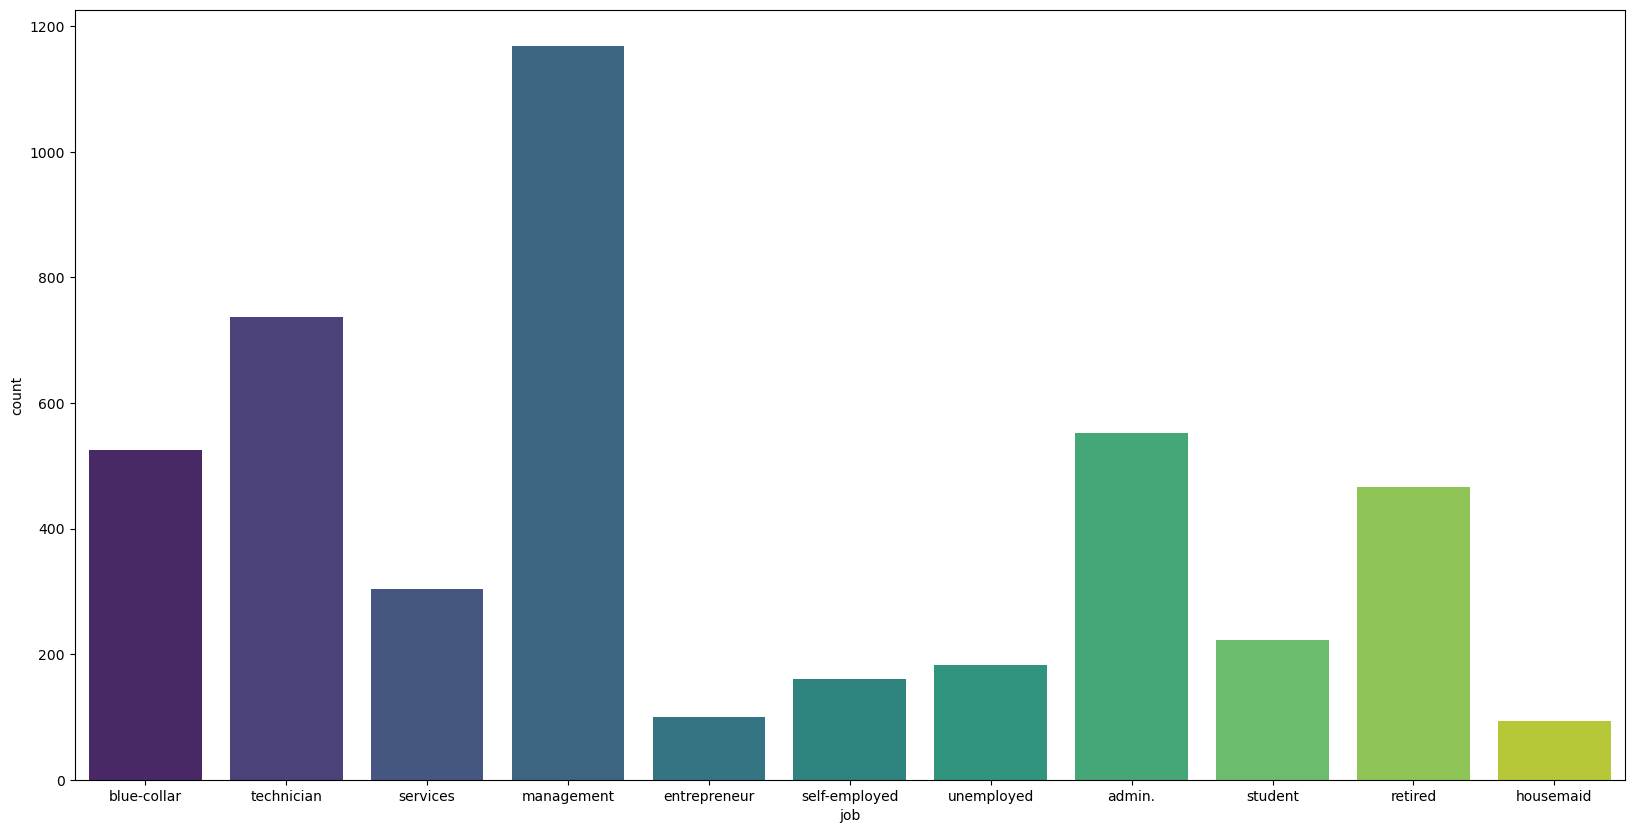

In [22]:
plt.figure(figsize=(20,10))
sns.countplot(x='job', data=df_yes, palette='viridis')
plt.show()

In [23]:
# plt.figure(figsize=(10, 6))

# corr_data=X
# corr_data['target']=y

# # Select only numeric features
# numeric_df = df.select_dtypes(include=['number'])

# sns.heatmap(corr_data.corr(), annot=True, fmt=".1f", cmap='coolwarm')

# plt.title("Correlation Matrix (Numeric Features Only)")
# plt.show()

X


,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,previous
12657,27,management,single,secondary,no,35,no,no,cellular,255,1,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,297,1,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,668,2,0
12660,31,technician,single,secondary,no,19,no,no,telephone,65,2,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,436,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,977,3,0
45207,71,retired,divorced,primary,no,1729,no,no,cellular,456,2,0
45208,72,retired,married,secondary,no,5715,no,no,cellular,1127,5,3
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,508,4,0


## Machine Learning

In [24]:

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

y=y.map({'yes': 1, 'no': 0})

# All columns with dtype "object" or "category"
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
# One-Hot Encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.head()


# def label_encoder_df(df):
#     df_encoded = df.copy()
#     le = LabelEncoder()
#     for col in df_encoded.select_dtypes(include=["object"]).columns:
#         df_encoded[col] = le.fit_transform(df_encoded[col])
#     return df_encoded

# X_encoded = label_encoder_df(X)
# y_df = y.to_frame() 
# y_encoded = label_encoder_df(y_df)
# print(X_encoded.head(),'\n', y_encoded.head())

X.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign',
       'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_secondary', 'education_tertiary',
       'contact_telephone'],
      dtype='object')

### Smote

In [25]:

# # Split into train and test (important: apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.4, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


pd.Series(y_train_res).value_counts()


target
0    18475
1     7390
Name: count, dtype: int64

In [26]:
scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train_res)
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.fit_transform(X_test)


# Artificial Neural Network - Classification

In [27]:
model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'), 
    Dropout(0.3),
    Dense(32, activation='relu'),  
    Dense(1, activation='sigmoid')                             
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=10,          
    restore_best_weights=True  
)

history = model.fit(
    X_train_scaled, y_train_res,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8275 - loss: 0.3989 - val_accuracy: 0.3909 - val_loss: 0.8944
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8626 - loss: 0.3207 - val_accuracy: 0.4595 - val_loss: 0.8992
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8637 - loss: 0.3121 - val_accuracy: 0.4253 - val_loss: 0.9666
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8629 - loss: 0.3090 - val_accuracy: 0.4212 - val_loss: 0.9897
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.8646 - loss: 0.3055 - val_accuracy: 0.4562 - val_loss: 0.9638
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - accuracy: 0.8667 - loss: 0.3024 - val_accuracy: 0.4181 - val_loss: 0.9877
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8665 - loss: 0.3012 - val_accuracy: 0.4848 - val_loss: 0.9328
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.8667 - loss: 0.2996 - val_accura

In [29]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - accuracy: 0.8655 - loss: 0.3158
Test Accuracy: 86.55%


In [30]:
y_pred_results = model.predict(X_test_scaled)

y_pred_results = [round(x[0]) for x in y_pred_results]

# Now compute accuracy and F1
acc = accuracy_score(y_test, y_pred_results)
f1  = f1_score(y_test, y_pred_results, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


print(classification_report(y_pred_results, y_test))

290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step
Accuracy: 0.8655
F1 Score: 0.8402
              precision    recall  f1-score   support

           0       0.97      0.88      0.93      8726
           1       0.24      0.60      0.34       547

    accuracy                           0.87      9273
   macro avg       0.61      0.74      0.63      9273
weighted avg       0.93      0.87      0.89      9273



# Traditional Classification Models

In [31]:
# Classification param grid
param_grid = {
    'Decision Tree': {
        'max_depth': [2, 4, 6],
        'random_state': [0]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10, 20],
        'random_state': [0],
    },
    'Logistic Regression': {
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
        'l1_ratio': [0.0, 0.5, 1.0],
        'C': [0.1, 1.0, 10],
        'max_iter': [2000]
    },
    'CatBoost': {
        'iterations': [100, 200],
        'learning_rate': [0.05, 0.1],
        'depth': [ 6, 8],
        'scale_pos_weight': [1, 2]   # imbalance handling
    }
}

# Classification models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=0)
}


In [32]:
results, trad_models_results = init_training(X_train_scaled, y_train_res, X_test_scaled, y_test, model, param_grid, cv=3, print_results=True)

DecisionTreeClassifier(random_state=0) Decision Tree
Model: Decision Tree:
Best Params:{'max_depth': 6, 'random_state': 0}
Accuracy score for train: 0.8321, test: 0.8365.
F1 score for train: 0.8292, test F1: 0.8456


              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7919
           1       0.45      0.60      0.52      1354

    accuracy                           0.84      9273
   macro avg       0.69      0.74      0.71      9273
weighted avg       0.86      0.84      0.85      9273

RandomForestClassifier(random_state=0) Random Forest
Model: Random Forest:
Best Params:{'max_depth': 20, 'n_estimators': 100, 'random_state': 0}
Accuracy score for train: 0.9923, test: 0.8538.
F1 score for train: 0.9923, test F1: 0.8538


              precision    recall  f1-score   support

           0       0.91      0.91      0.91      7919
           1       0.50      0.50      0.50      1354

    accuracy                           0.85      9273

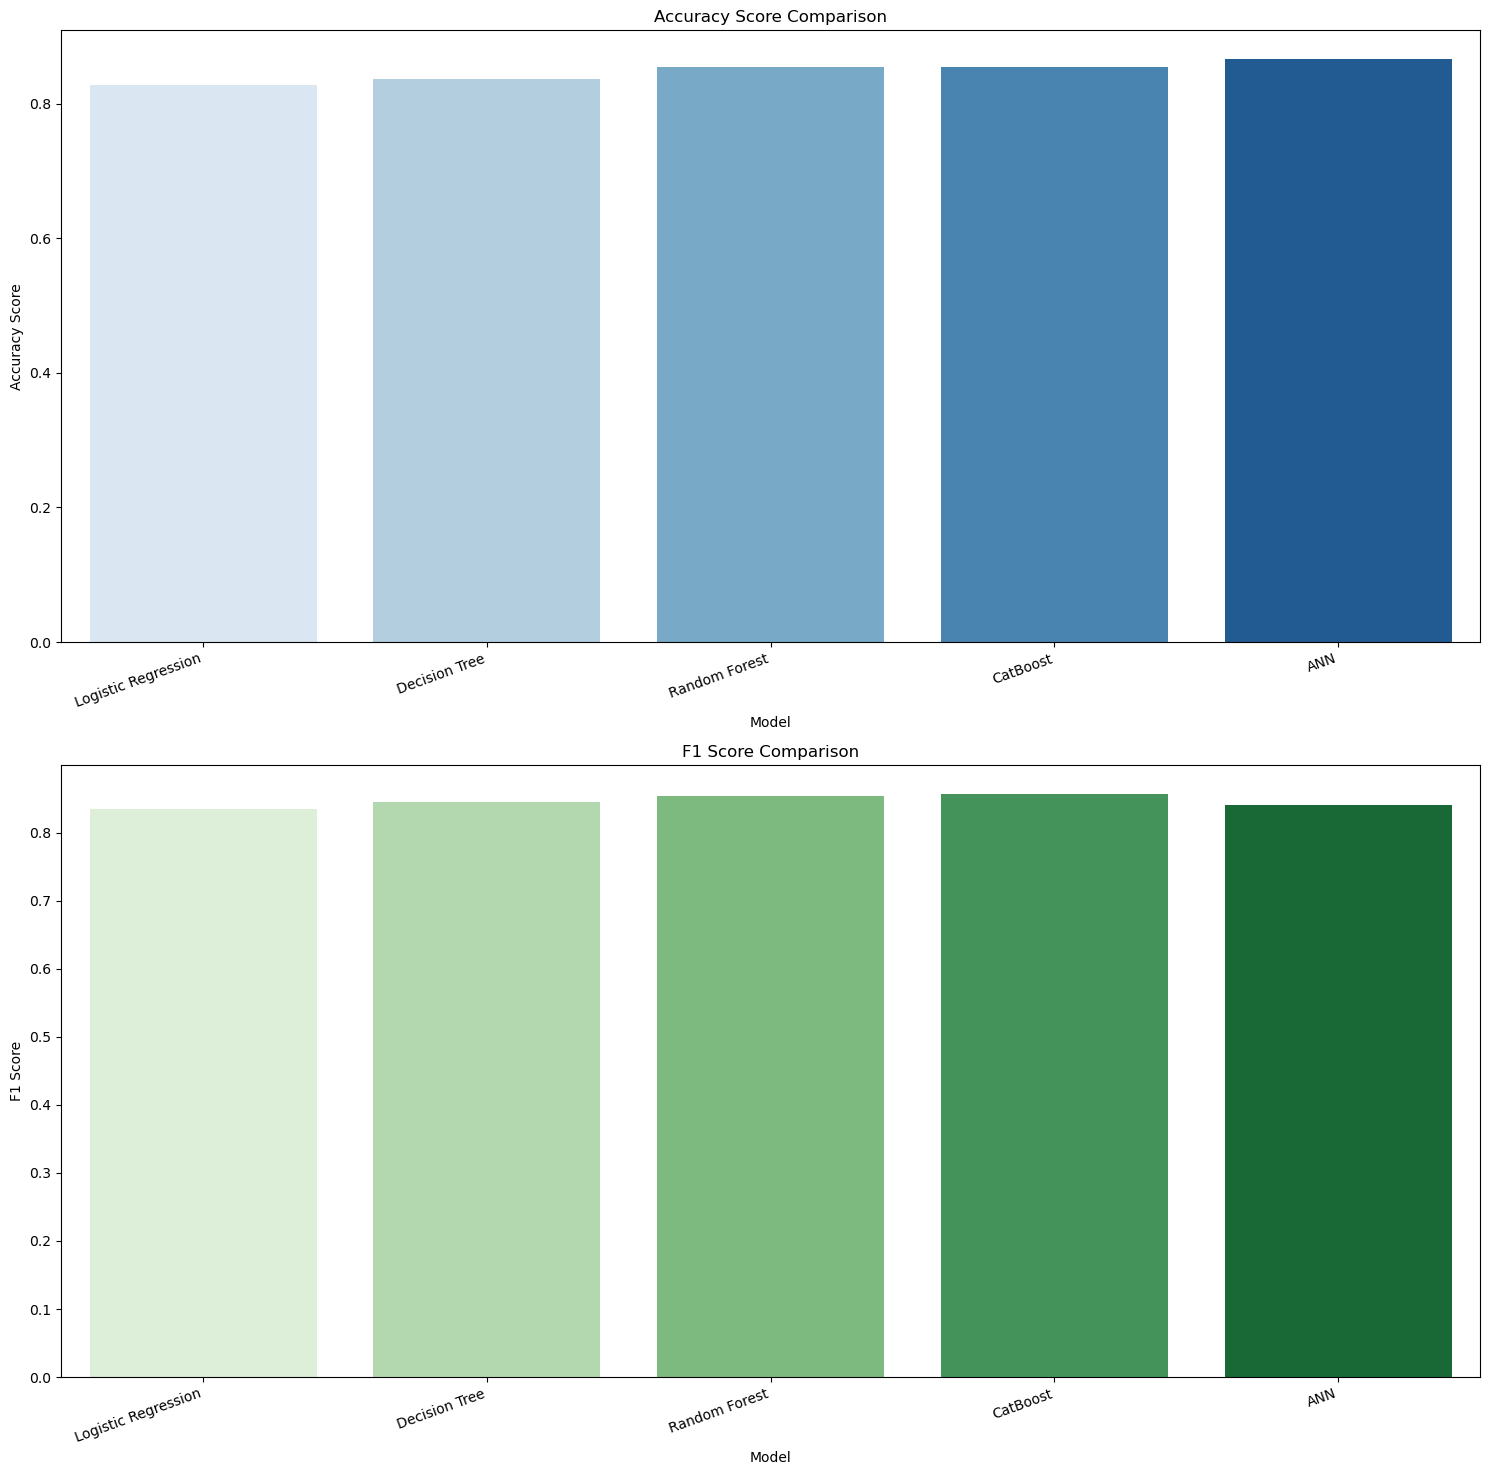

In [33]:
results.append({
    'Model': 'ANN',
    'Accuracy': acc,
    'F1': f1
})

gen_model_training_summary(results)

In [46]:
save_model(model, scaler, 'ann_model')

----Exporting model locally.
----Exporting scaler
Model was saved locally as ann_model.h5
----Uploading model to HDFS.
----Uploading scaler to HDFS.
Model saved to HDFS at /marketing_campaign/models/ann_model.h5
